# $(SASA) Models - Kmeans$

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [3]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
2329,16,92,"(0.1771043759930183, 0.8300521931250568)","(-0.087, -1.184, 0.056, 1.09)",1,1.0,"(-0.111, -0.994, 0.078, 0.914)",1.0,1.0,"(-0.13, -0.804, 0.096, 0.744)"
606,34,22,"(0.1859246409325834, 0.509421113235871)","(-0.274, -1.172, 0.061, 1.139)",1,1.0,"(-0.298, -0.977, 0.083, 0.853)",0.0,1.0,"(-0.317, -1.174, 0.1, 1.186)"
1968,16,78,"(0.0956613712139894, 0.231794730405182)","(0.014, 0.048, -0.024, -0.116)",0,1.0,"(0.015, -0.161, -0.026, 0.498)",0.0,1.0,"(0.012, -0.371, -0.016, 1.109)"
541,93,19,"(0.0642916329828742, 1.239005358213764)","(0.882, 2.81, -0.013, -0.925)",0,1.0,"(0.938, 2.623, -0.032, -0.811)",1.0,1.0,"(0.99, 2.81, -0.048, -0.93)"
1709,31,67,"(0.0550547819736606, 0.7277451834527079)","(-0.114, -0.245, 0.13, 0.555)",1,1.0,"(-0.119, -0.056, 0.141, 0.389)",0.0,1.0,"(-0.12, -0.247, 0.149, 0.611)"
...,...,...,...,...,...,...,...,...,...,...
1291,13,53,"(0.2444473003074412, 0.4846825463128728)","(-0.067, 0.214, 0.04, -0.177)",1,1.0,"(-0.063, 0.41, 0.037, -0.499)",1.0,1.0,"(-0.055, 0.607, 0.027, -0.823)"
603,31,22,"(0.1859246409325834, 0.509421113235871)","(-0.228, -0.583, 0.031, 0.184)",0,1.0,"(-0.239, -0.779, 0.034, 0.501)",0.0,1.0,"(-0.255, -0.976, 0.044, 0.818)"
604,32,22,"(0.1859246409325834, 0.509421113235871)","(-0.239, -0.779, 0.034, 0.501)",0,1.0,"(-0.255, -0.976, 0.044, 0.818)",0.0,1.0,"(-0.274, -1.172, 0.061, 1.139)"
102,14,5,"(0.3551867425587211, 0.959194989729514)","(0.013, -0.349, 0.019, 0.33)",0,1.0,"(0.006, -0.539, 0.025, 0.521)",1.0,1.0,"(-0.005, -0.349, 0.036, 0.339)"


In [4]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
1147,45,46,"(0.5759890361457483, 0.539204361971833)","(-0.251, -0.221, 0.114, -0.061)",0,1.0,"(-0.255, -0.424, 0.113, 0.4)",1.0,1.0,"(-0.263, -0.225, 0.121, 0.04)",-0.251,-0.221,0.114,-0.061,-0.255,-0.424,0.113,0.400,0.575989,0.539204
2162,13,84,"(0.0433876892251688, 0.5641318888962644)","(0.01, -0.157, 0.073, 0.373)",0,1.0,"(0.007, -0.351, 0.081, 0.641)",1.0,1.0,"(-0.0, -0.159, 0.093, 0.414)",0.010,-0.157,0.073,0.373,0.007,-0.351,0.081,0.641,0.043388,0.564132
1989,8,79,"(0.1768018230473693, 0.6492383504943047)","(0.027, -0.047, 0.051, 0.052)",1,1.0,"(0.026, 0.145, 0.052, -0.173)",0.0,1.0,"(0.029, -0.048, 0.048, 0.078)",0.027,-0.047,0.051,0.052,0.026,0.145,0.052,-0.173,0.176802,0.649238
913,18,37,"(0.4975531073717145, 0.2612437398996861)","(-0.022, -0.01, 0.142, 0.604)",0,1.0,"(-0.022, -0.232, 0.154, 1.497)",0.0,1.0,"(-0.027, -0.454, 0.184, 2.396)",-0.022,-0.010,0.142,0.604,-0.022,-0.232,0.154,1.497,0.497553,0.261244
1389,4,57,"(0.4858968354133477, 0.4002511587990111)","(0.043, 0.404, -0.026, -0.981)",0,1.0,"(0.051, 0.2, -0.046, -0.486)",0.0,1.0,"(0.055, -0.004, -0.055, -0.003)",0.043,0.404,-0.026,-0.981,0.051,0.200,-0.046,-0.486,0.485897,0.400251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,5,59,"(0.0516954554163139, 0.1524358046184122)","(-0.006, 0.259, 0.029, -0.993)",0,1.0,"(-0.0, 0.034, 0.009, -0.037)",1.0,1.0,"(0.0, 0.257, 0.008, -0.956)",-0.006,0.259,0.029,-0.993,-0.000,0.034,0.009,-0.037,0.051695,0.152436
1411,26,57,"(0.4858968354133477, 0.4002511587990111)","(-0.077, -0.38, 0.096, 0.284)",0,1.0,"(-0.085, -0.588, 0.101, 0.841)",1.0,1.0,"(-0.097, -0.385, 0.118, 0.391)",-0.077,-0.380,0.096,0.284,-0.085,-0.588,0.101,0.841,0.485897,0.400251
1993,12,79,"(0.1768018230473693, 0.6492383504943047)","(0.031, 0.336, 0.047, -0.373)",0,1.0,"(0.038, 0.142, 0.04, -0.123)",0.0,1.0,"(0.041, -0.051, 0.037, 0.126)",0.031,0.336,0.047,-0.373,0.038,0.142,0.040,-0.123,0.176802,0.649238
708,18,24,"(0.381115827959413, 0.5947037963670837)","(-0.049, -0.413, 0.079, 0.877)",0,1.0,"(-0.057, -0.61, 0.097, 1.211)",1.0,1.0,"(-0.07, -0.415, 0.121, 0.936)",-0.049,-0.413,0.079,0.877,-0.057,-0.610,0.097,1.211,0.381116,0.594704


# Initialization by Random Partitioning

In [ ]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]

In [6]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
1147,45,46,"(0.5759890361457483, 0.539204361971833)","(-0.251, -0.221, 0.114, -0.061)",0,1.0,"(-0.255, -0.424, 0.113, 0.4)",1.0,1.0,"(-0.263, -0.225, 0.121, 0.04)",...,-0.221,0.114,-0.061,-0.255,-0.424,0.113,0.400,0.575989,0.539204,0.0
2162,13,84,"(0.0433876892251688, 0.5641318888962644)","(0.01, -0.157, 0.073, 0.373)",0,1.0,"(0.007, -0.351, 0.081, 0.641)",1.0,1.0,"(-0.0, -0.159, 0.093, 0.414)",...,-0.157,0.073,0.373,0.007,-0.351,0.081,0.641,0.043388,0.564132,1.0
1989,8,79,"(0.1768018230473693, 0.6492383504943047)","(0.027, -0.047, 0.051, 0.052)",1,1.0,"(0.026, 0.145, 0.052, -0.173)",0.0,1.0,"(0.029, -0.048, 0.048, 0.078)",...,-0.047,0.051,0.052,0.026,0.145,0.052,-0.173,0.176802,0.649238,0.0
913,18,37,"(0.4975531073717145, 0.2612437398996861)","(-0.022, -0.01, 0.142, 0.604)",0,1.0,"(-0.022, -0.232, 0.154, 1.497)",0.0,1.0,"(-0.027, -0.454, 0.184, 2.396)",...,-0.010,0.142,0.604,-0.022,-0.232,0.154,1.497,0.497553,0.261244,3.0
1389,4,57,"(0.4858968354133477, 0.4002511587990111)","(0.043, 0.404, -0.026, -0.981)",0,1.0,"(0.051, 0.2, -0.046, -0.486)",0.0,1.0,"(0.055, -0.004, -0.055, -0.003)",...,0.404,-0.026,-0.981,0.051,0.200,-0.046,-0.486,0.485897,0.400251,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1480,5,59,"(0.0516954554163139, 0.1524358046184122)","(-0.006, 0.259, 0.029, -0.993)",0,1.0,"(-0.0, 0.034, 0.009, -0.037)",1.0,1.0,"(0.0, 0.257, 0.008, -0.956)",...,0.259,0.029,-0.993,-0.000,0.034,0.009,-0.037,0.051695,0.152436,4.0
1411,26,57,"(0.4858968354133477, 0.4002511587990111)","(-0.077, -0.38, 0.096, 0.284)",0,1.0,"(-0.085, -0.588, 0.101, 0.841)",1.0,1.0,"(-0.097, -0.385, 0.118, 0.391)",...,-0.380,0.096,0.284,-0.085,-0.588,0.101,0.841,0.485897,0.400251,3.0
1993,12,79,"(0.1768018230473693, 0.6492383504943047)","(0.031, 0.336, 0.047, -0.373)",0,1.0,"(0.038, 0.142, 0.04, -0.123)",0.0,1.0,"(0.041, -0.051, 0.037, 0.126)",...,0.336,0.047,-0.373,0.038,0.142,0.040,-0.123,0.176802,0.649238,0.0
708,18,24,"(0.381115827959413, 0.5947037963670837)","(-0.049, -0.413, 0.079, 0.877)",0,1.0,"(-0.057, -0.61, 0.097, 1.211)",1.0,1.0,"(-0.07, -0.415, 0.121, 0.936)",...,-0.413,0.079,0.877,-0.057,-0.610,0.097,1.211,0.381116,0.594704,2.0


## Initial Training 

In [7]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        x, y = model.get_features_targets(group_data)
        trainer = model.train(x, y, num_epochs=1000)
        train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [8]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.19216135144233704, 0.4658159613609314, 0.01...",1.150594,0.939009
1,1,"[0.1895418018102646, 0.46229514479637146, 0.01...",1.140455,0.931511
2,2,"[0.18697455525398254, 0.4587933421134949, 0.01...",1.130404,0.924066
3,3,"[0.18445990979671478, 0.45531025528907776, 0.0...",1.120442,0.916673
4,4,"[0.1819980889558792, 0.45184585452079773, 0.01...",1.110568,0.909333


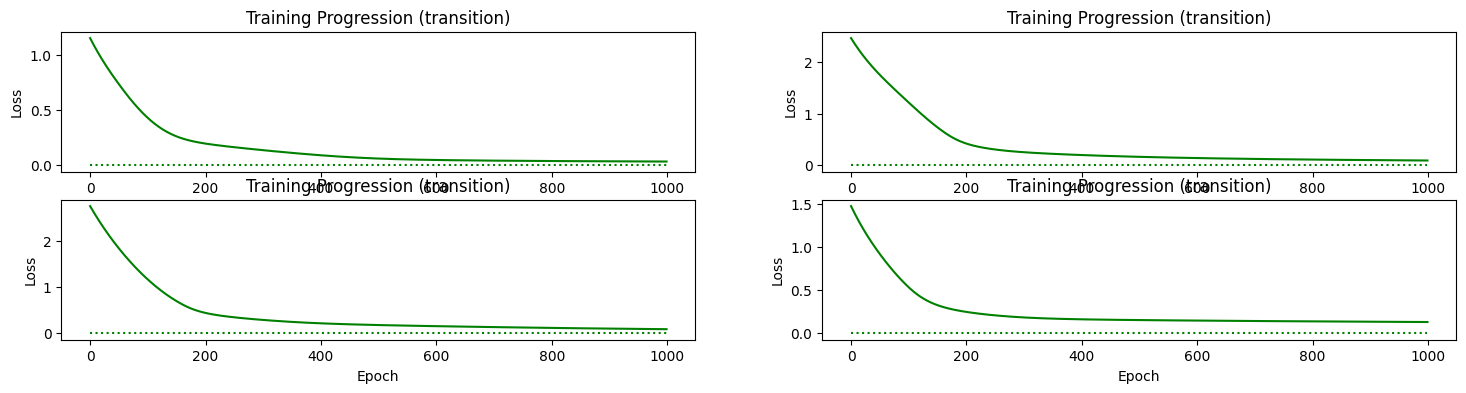

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [ ]:
def evaluate(models, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        
        results = data.get_evaluation_metrics(pred, p=False)
        prediction_dataset[f'rse_model_{i}'] = results['rse']
        prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

        prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
        prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
        prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
        prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

        prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
        prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
        prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
        prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


    return prediction_dataset

In [ ]:
prediction_dataset = evaluate(models, params, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
1147,45,46,"(0.5759890361457483, 0.539204361971833)","(-0.251, -0.221, 0.114, -0.061)",0,1.0,"(-0.255, -0.424, 0.113, 0.4)",1.0,1.0,"(-0.263, -0.225, 0.121, 0.04)",...,0.238,0.498573,0.056,0.061,0.025,0.096,0.426728,0.429692,0.558753,0.579121
2162,13,84,"(0.0433876892251688, 0.5641318888962644)","(0.01, -0.157, 0.073, 0.373)",0,1.0,"(0.007, -0.351, 0.081, 0.641)",1.0,1.0,"(-0.0, -0.159, 0.093, 0.414)",...,0.059,0.485087,0.018,0.006,0.015,0.020,0.410908,0.420108,0.534772,0.574559
1989,8,79,"(0.1768018230473693, 0.6492383504943047)","(0.027, -0.047, 0.051, 0.052)",1,1.0,"(0.026, 0.145, 0.052, -0.173)",0.0,1.0,"(0.029, -0.048, 0.048, 0.078)",...,0.125,0.488826,0.009,0.028,0.020,0.068,0.407161,0.423941,0.546763,0.577440
913,18,37,"(0.4975531073717145, 0.2612437398996861)","(-0.022, -0.01, 0.142, 0.604)",0,1.0,"(-0.022, -0.232, 0.154, 1.497)",0.0,1.0,"(-0.027, -0.454, 0.184, 2.396)",...,0.442,0.485380,0.007,0.054,0.005,0.376,0.406328,0.428472,0.510791,0.595930
1389,4,57,"(0.4858968354133477, 0.4002511587990111)","(0.043, 0.404, -0.026, -0.981)",0,1.0,"(0.051, 0.2, -0.046, -0.486)",0.0,1.0,"(0.055, -0.004, -0.055, -0.003)",...,0.331,0.488223,0.012,0.053,0.012,0.254,0.408410,0.428298,0.527578,0.588606


In [12]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
    #     'rse_model_0',
    #     'rse_model_1',
    #     'rse_model_2',
    #     'rse_model_3',
    #     'rse_model_4',
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [13]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

best_model
0    42
3    27
4    15
1    12
2     4
Name: count, dtype: int64


,best_rse
count,2504.000000
mean,0.183605
std,0.222902
min,0.010000
25%,0.086000
50%,0.137500
75%,0.208000
max,5.019000


# LOOP

In [14]:

# while True: 
for _ in range(10): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'epis_changed: {check}')
    if check == 0:
        break
    

    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, prediction_dataset)

    prediction_dataset = reagroup(prediction_dataset)
    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1710
best_model
4    36
0    35
3    15
1    12
2     2
Name: count, dtype: int64
best_rse    0.101445
dtype: float64
epis_changed: 1537
best_model
4    40
0    35
1    14
3     9
2     2
Name: count, dtype: int64
best_rse    0.083597
dtype: float64
epis_changed: 1537
best_model
4    42
0    35
1    14
3     7
2     2
Name: count, dtype: int64
best_rse    0.070594
dtype: float64
epis_changed: 1574
best_model
4    42
0    36
1    14
3     5
2     3
Name: count, dtype: int64
best_rse    0.062872
dtype: float64
epis_changed: 1609
best_model
4    40
0    36
1    14
3     5
2     5
Name: count, dtype: int64
best_rse    0.056665
dtype: float64
epis_changed: 1631
best_model
4    38
0    36
1    14
2     7
3     5
Name: count, dtype: int64
best_rse    0.051749
dtype: float64
epis_changed: 1631
best_model
4    36
0    34
1    14
2    11
3     5
Name: count, dtype: int64
best_rse    0.047911
dtype: float64
epis_changed: 1593
best_model
4    35
0    31
2    16
1    14
3     4
Name: 